In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, boxcox_normmax
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

In [3]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
test_ids = test["Id"]
train = train.drop("Id", axis=1)
test = test.drop("Id", axis=1)
print(train.shape, test.shape)

(1460, 80) (1459, 79)


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [5]:
X=train.drop(['SalePrice'], axis=1)
y=train['SalePrice']

X_train,X_val,y_train,y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include='object').columns


advanced_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42
)

print("Đang tiến hành điền khuyết bằng Machine Learning...")
X_train[numeric_cols] = advanced_imputer.fit_transform(
    X_train[numeric_cols]
)

X_val[numeric_cols] = advanced_imputer.transform(X_val[numeric_cols])
test[numeric_cols] = advanced_imputer.transform(test[numeric_cols])

Đang tiến hành điền khuyết bằng Machine Learning...


In [7]:
missing = pd.concat([X_train.isnull().sum(),X_train.dtypes],axis=1,keys=["Train","DataType"])
missing = missing[missing["Train"]> 0].sort_values(by="Train",ascending=False)
missing

,Train,DataType
PoolQC,1162,object
MiscFeature,1122,object
Alley,1094,object
Fence,935,object
MasVnrType,683,object
FireplaceQu,547,object
GarageFinish,64,object
GarageQual,64,object
GarageType,64,object
GarageCond,64,object


In [8]:
def handle_missing(df):
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType',
                 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                 'BsmtFinType1', 'BsmtFinType2']
    for col in none_cols:
        df[col] = df[col].fillna('None')

    zero_cols = ['MasVnrArea', 'GarageYrBlt', 'GarageArea', 'GarageCars','BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF','BsmtFullBath', 'BsmtHalfBath']
    for col in zero_cols:
        df[col] = df[col].fillna(0)

    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda train: train.fillna(train.median()))

    remaining_cat = ['Electrical', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'SaleType',
                     'KitchenQual', 'Functional']
    for col in remaining_cat:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    return df
X_train = handle_missing(X_train)
X_val = handle_missing(X_val)
test = handle_missing(test)

In [9]:
def feature_extraction(df):
    df = df.copy()
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])

    df['TotalBath'] = (df['FullBath'] + 0.5*df['HalfBath'] +
                      df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])

    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['IsNew'] = (df['YearBuilt'] == df['YrSold']).astype(int)

    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)

    df['SF_per_Room'] = df['TotalSF'] / (df['TotRmsAbvGrd'] + 1)
    df['LotArea_per_SF'] = df['LotArea'] / (df['TotalSF'] + 1)

    return df

X_train = feature_extraction(X_train)
X_val = feature_extraction(X_val)
test = feature_extraction(test)

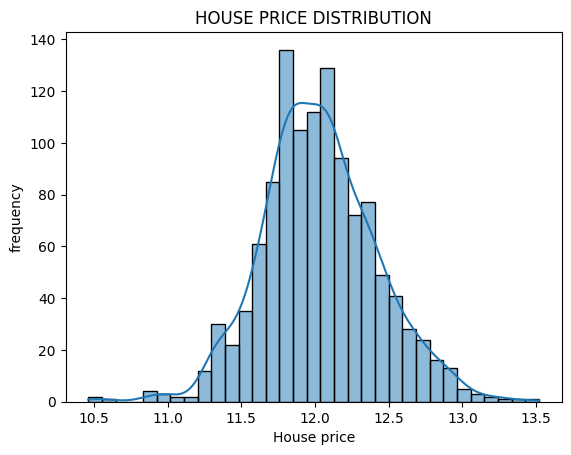

Skewness: 0.12472979656043416


In [29]:
sns.histplot(y_train, kde=True)
plt.title("HOUSE PRICE DISTRIBUTION")
plt.xlabel("House price")
plt.ylabel("frequency")
plt.show()
print("Skewness:", skew(y_train))

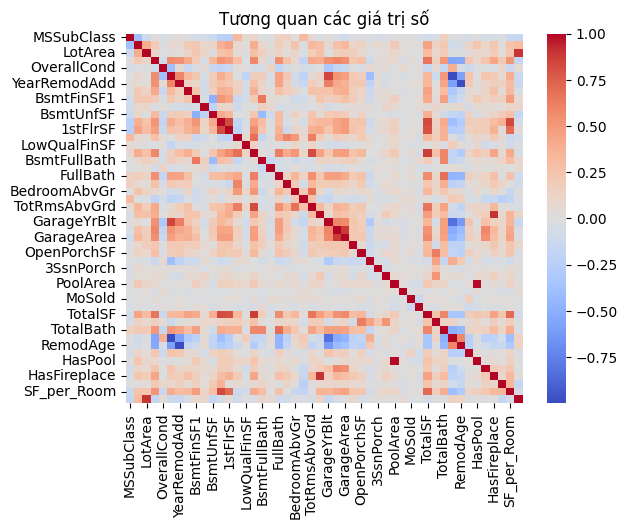

In [11]:
num_cols=X_train.select_dtypes(include=np.number).columns
corr = X_train[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Tương quan các giá trị số")
plt.show()

In [12]:
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)

def get_skewed_features(df_train, threshold=0.75):
    numeric_feats = df_train.select_dtypes(include=np.number).columns
    skewed_feats = df_train[numeric_feats].apply(lambda x: skew(x.dropna()))
    return skewed_feats[(abs(skewed_feats) > threshold)].index

skewed_cols = get_skewed_features(X_train)

def apply_skew_fix(df, skewed_cols):
    df = df.copy()
    for feat in skewed_cols:
        if df[feat].nunique() > 1:
            df[feat] = np.log1p(df[feat])
    return df

X_train = apply_skew_fix(X_train, skewed_cols)
X_val = apply_skew_fix(X_val, skewed_cols)
test = apply_skew_fix(test, skewed_cols)

In [13]:
def get_rare_categories(df_train, threshold=0.05):
    rare_dict = {}
    for col in df_train.select_dtypes(include='object').columns:
        freq = df_train[col].value_counts(normalize=True)
        rare_dict[col] = freq[freq < threshold].index
    return rare_dict

rare_mapping = get_rare_categories(X_train)

def apply_rare_categories(df, rare_mapping):
    df = df.copy()
    for col, rare_cats in rare_mapping.items():
        if len(rare_cats) > 0:
            df[col] = df[col].replace(rare_cats, 'Rare')
    return df

X_train = apply_rare_categories(X_train, rare_mapping)
X_val = apply_rare_categories(X_val, rare_mapping)
test = apply_rare_categories(test, rare_mapping)

In [14]:
cat_cols = X_train.select_dtypes(include='object').columns

#Encoder => One Hot
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[cat_cols]),columns=encoder.get_feature_names_out())
X_train = pd.concat([X_train.drop(cat_cols, axis=1).reset_index(drop=True), X_train_encoded], axis=1)

X_val_encoded = pd.DataFrame(encoder.transform(X_val[cat_cols]),columns=encoder.get_feature_names_out())
X_val = pd.concat([X_val.drop(cat_cols, axis=1).reset_index(drop=True), X_val_encoded], axis=1)

test = pd.concat([test.drop(cat_cols, axis=1).reset_index(drop=True),pd.DataFrame(encoder.transform(test[cat_cols]),columns=encoder.get_feature_names_out())], axis=1)

print("Object columns:")
print(X_train.select_dtypes(include='object').columns.tolist())

print("\nData types:")
print(X_train.dtypes.value_counts())
#Scaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
test = pd.DataFrame(scaler.transform(test), columns=test.columns)

#Feature Selection bằng Lasso
lasso = Lasso(alpha=0.0005, random_state=42)
lasso.fit(X_train, y_train)
selected_features = X_train.columns[np.abs(lasso.coef_) !=0]
print(f"Số features sau Lasso: {len(selected_features)}")

X_train = X_train[selected_features]
X_val = X_val[selected_features]
test = test[selected_features]

Object columns:
[]

Data types:
float64    192
int64        1
Name: count, dtype: int64
Số features sau Lasso: 126


In [15]:
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()

In [21]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [22]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import OrdinalEncoder

In [23]:
patience = 50

et_model = ExtraTreesRegressor(n_estimators=500, random_state=42)

xgb_model = XGBRegressor(
    learning_rate=0.05,
    n_estimators=1000,
    max_depth=4,
    early_stopping_rounds=patience,
    random_state=42
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)


lgbm_model = LGBMRegressor(
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=15,
    early_stopping_rounds=patience,
    random_state=42
)
lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])


cat_model = CatBoostRegressor(
    learning_rate=0.05,
    iterations=1000,
    early_stopping_rounds=patience,
    random_state=42
)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3064
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 118
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Start training from score 12.030658
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[153]	valid_0's l2: 0.0185769


CatBoostRegressor(early_stopping_rounds=50, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_state=42)

In [26]:
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
import numpy as np
import pandas as pd

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {
    "Extra Trees": et_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

val_predictions = {}
test_predictions = {}

for name, model in models.items():

    if name == "Extra Trees":
        model.fit(X_train, y_train)
        best_iter = "N/A (FIXED NO OF TREES)"

    elif name == "CatBoost":
        model.fit(
            X_train,
            y_train,
            eval_set=(X_val, y_val),
            verbose=False
                    )
        best_iter = model.get_best_iteration()

    elif name == "XGBoost":
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        best_iter = model.best_iteration

    elif name == "LightGBM":
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)]
        )
        best_iter = model.best_iteration_

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(test)

    val_predictions[name] = pred_val
    test_predictions[name] = pred_test

    train_rmse = rmse(y_train, pred_train)
    val_rmse = rmse(y_val, pred_val)

    print(f"\n{name}")
    print(f"Best iteration : {best_iter}")
    print(f"Train RMSE     : {train_rmse:.5f}")
    print(f"Validation RMSE: {val_rmse:.5f}")

    if val_rmse - train_rmse > 0.05:
        print("=> signs of Overfitting")

model_names = list(models.keys())

val_pred_matrix = np.column_stack([
    val_predictions[name]
    for name in model_names
])

def objective(weights):
    pred = val_pred_matrix @ weights
    return rmse(y_val, pred)

constraints = (
    {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    },
)

bounds = [(0, 1)] * len(model_names)

initial_weights = np.ones(len(model_names)) / len(model_names)
result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

best_weights = result.x

print("\nOPTIMAL ENSEMBLE WEIGHTS")
print("-" * 40)

for name, w in zip(model_names, best_weights):
    print(f"{name:<15}: {w:.4f}")

print("-" * 40)

final_val_pred = val_pred_matrix @ best_weights

ensemble_rmse = rmse(y_val, final_val_pred)

print(f"Validation RMSE Ensemble: {ensemble_rmse:.5f}")

test_pred_matrix = np.column_stack([
    test_predictions[name]
    for name in model_names
])
final_log_pred = test_pred_matrix @ best_weights

final_pred = np.expm1(final_log_pred)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_pred
})

submission.to_csv("submission.csv", index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(



Extra Trees
Best iteration : N/A (FIXED NO OF TREES)
Train RMSE     : 0.00000
Validation RMSE: 0.15066
=> signs of Overfitting

XGBoost
Best iteration : 553
Train RMSE     : 0.03095
Validation RMSE: 0.13338
=> signs of Overfitting
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3064
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 118
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Start training from score 12.030658
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration i

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



CatBoost
Best iteration : 546
Train RMSE     : 0.04586
Validation RMSE: 0.12913
=> signs of Overfitting

OPTIMAL ENSEMBLE WEIGHTS
----------------------------------------
Extra Trees    : 0.0000
XGBoost        : 0.2910
LightGBM       : 0.0000
CatBoost       : 0.7090
----------------------------------------
Validation RMSE Ensemble: 0.12850
